# 實作cGAN演算法
### 程式修改自[Kaggle PyTorch Conditional GAN](https://www.kaggle.com/arturlacerda/pytorch-conditional-gan)

## 載入套件

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from torchvision.utils import make_grid

## 設定參數

In [ ]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 64  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'cuda'

## 載入 FashionMNIST 資料

In [3]:
# 轉換
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

dataset = FashionMNIST(PATH_DATASETS, train=True, download=True, transform=transform)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


In [4]:
dataset[0][0]

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

## 定義生成神經網路

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # 設定嵌入層，作為 Label 的輸入
        self.label_emb = nn.Embedding(10, 10)

        self.model = nn.Sequential(
            nn.Linear(110, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, labels: torch.Tensor):
        z = z.view(z.size(0), 100)
        c = self.label_emb(labels)
        x = torch.cat([z, c], 1)  # 合併輸入
        out: torch.Tensor = self.model(x)
        return out.view(x.size(0), 28, 28)

## 定義判別神經網路

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # 設定嵌入層，作為 Label 的輸入
        self.label_emb = nn.Embedding(10, 10)

        self.model = nn.Sequential(
            nn.Linear(794, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor, labels: torch.Tensor):
        x = x.view(x.size(0), 784)
        c = self.label_emb(labels)
        x = torch.cat([x, c], 1)  # 合併輸入
        out: torch.Tensor = self.model(x)
        return out.squeeze()

## 建立模型

In [7]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

## 設定損失函數、優化器(optimizer)

In [8]:
criterion = nn.BCELoss()
d_optimizer = optim.Adam(discriminator.parameters(), lr=1e-4)
g_optimizer = optim.Adam(generator.parameters(), lr=1e-4)

## 定義生成網路訓練函數

In [9]:
def generator_train_step(
    batch_size: int,
    discriminator: nn.Module,
    generator: nn.Module,
    g_optimizer: optim.Optimizer,
    criterion: nn.Module,
) -> float:
    g_optimizer.zero_grad()
    z = torch.randn(batch_size, 100).to(device)
    fake_labels = torch.LongTensor(np.random.randint(0, 10, batch_size)).to(device)  # 隨機亂數 [1, 10]
    fake_images = generator(z, fake_labels)
    validity = discriminator(fake_images, fake_labels)
    g_loss: torch.Tensor = criterion(validity, torch.ones(batch_size).to(device))
    g_loss.backward()
    g_optimizer.step()
    return g_loss.data.item()

## 定義判別網路訓練函數

In [10]:
def discriminator_train_step(
    batch_size: int,
    discriminator: nn.Module,
    generator: nn.Module,
    d_optimizer: optim.Optimizer,
    criterion: nn.Module,
    real_images: torch.Tensor,
    labels: torch.Tensor,
) -> float:
    d_optimizer.zero_grad()

    # 訓練真實影像
    real_validity = discriminator(real_images, labels)
    real_loss = criterion(real_validity, torch.ones(batch_size).to(device))

    # 訓練偽造影像
    z = torch.randn(batch_size, 100).to(device)
    fake_labels = torch.LongTensor(np.random.randint(0, 10, batch_size)).to(device)  # 隨機亂數 [1, 10]
    fake_images = generator(z, fake_labels)
    fake_validity = discriminator(fake_images, fake_labels)
    fake_loss = criterion(fake_validity, torch.zeros(batch_size).to(device))

    d_loss: torch.Tensor = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    return d_loss.data.item()

## 訓練

Starting epoch 0...
g_loss: 3.980252981185913, d_loss: 0.4414048194885254


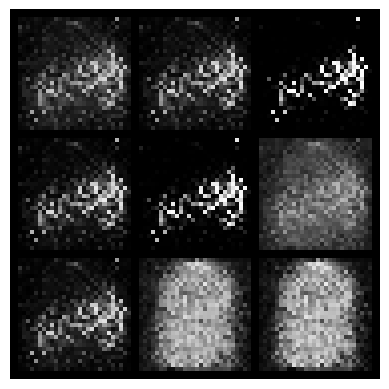

Starting epoch 1...
g_loss: 4.297554969787598, d_loss: 0.3394596576690674


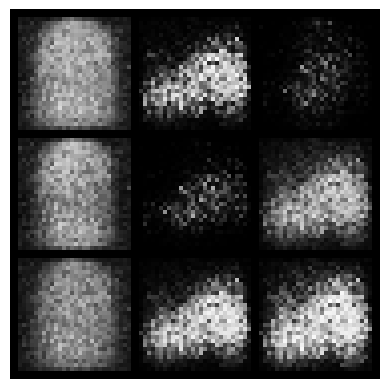

Starting epoch 2...
g_loss: 1.9280421733856201, d_loss: 0.4129061698913574


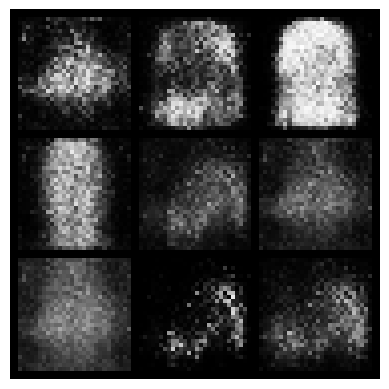

Starting epoch 3...
g_loss: 3.1709914207458496, d_loss: 0.26373565196990967


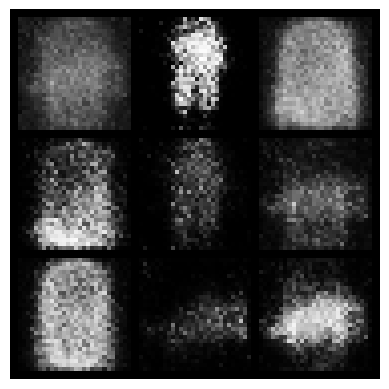

Starting epoch 4...
g_loss: 3.085550308227539, d_loss: 0.4303012788295746


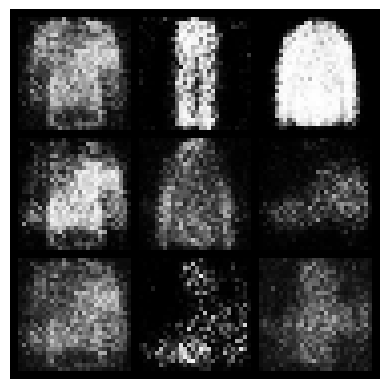

Starting epoch 5...
g_loss: 2.2205233573913574, d_loss: 0.5056192874908447


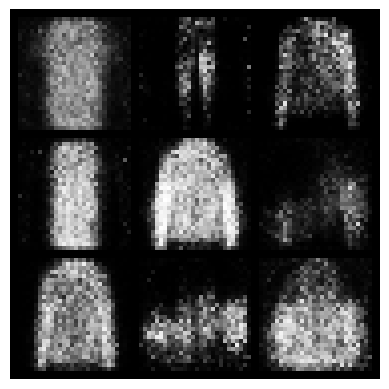

Starting epoch 6...
g_loss: 1.8753511905670166, d_loss: 0.5502310991287231


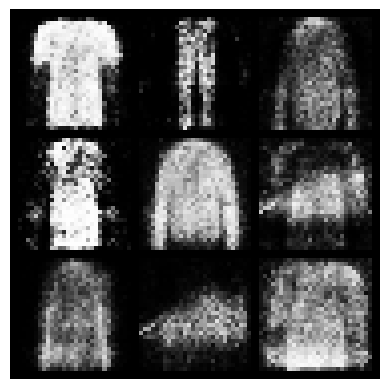

Starting epoch 7...
g_loss: 2.6340198516845703, d_loss: 0.6152800917625427


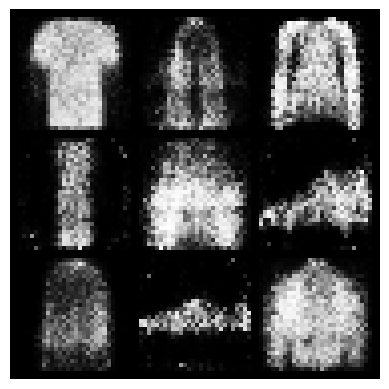

Starting epoch 8...
g_loss: 1.6813945770263672, d_loss: 0.6273891925811768


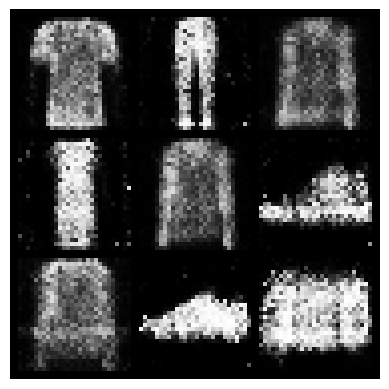

Starting epoch 9...
g_loss: 2.4927945137023926, d_loss: 0.6961936950683594


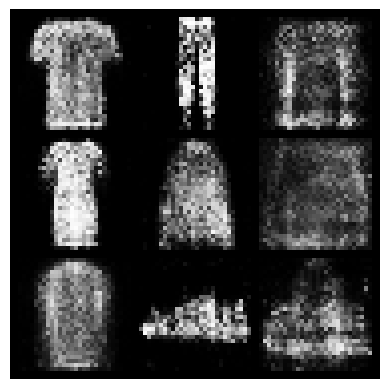

Starting epoch 10...
g_loss: 1.8182332515716553, d_loss: 1.135457992553711


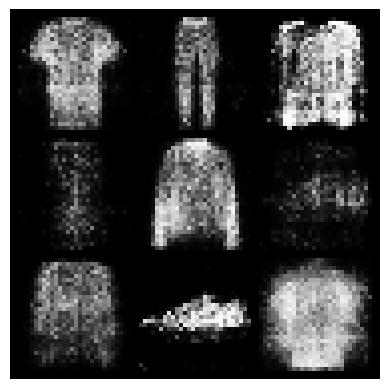

Starting epoch 11...
g_loss: 1.5574510097503662, d_loss: 0.7466798424720764


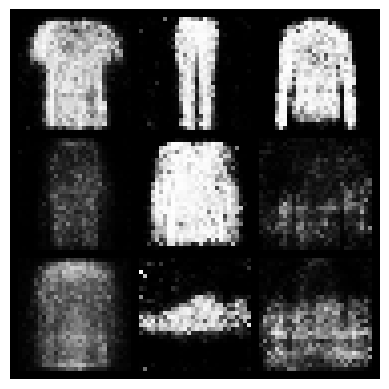

Starting epoch 12...
g_loss: 1.5683586597442627, d_loss: 0.8193686008453369


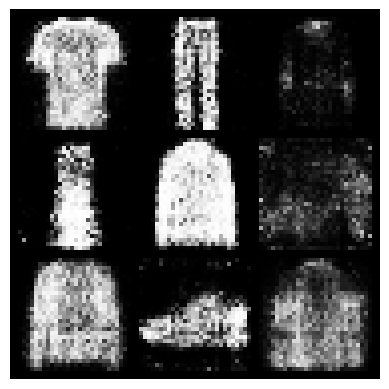

Starting epoch 13...
g_loss: 1.5823304653167725, d_loss: 1.0192638635635376


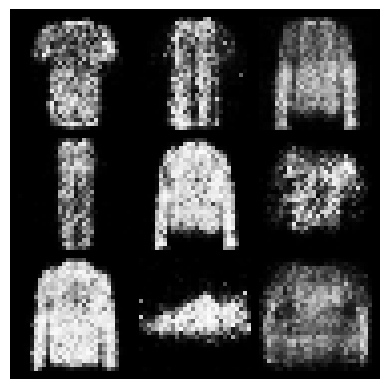

Starting epoch 14...
g_loss: 1.538743019104004, d_loss: 0.9742283225059509


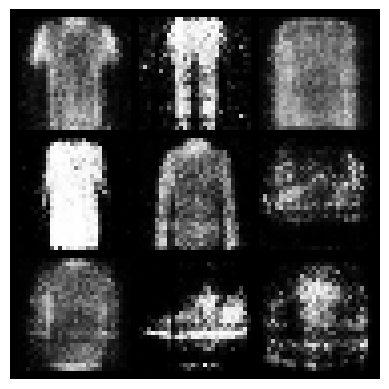

Starting epoch 15...
g_loss: 1.5880405902862549, d_loss: 0.8274931907653809


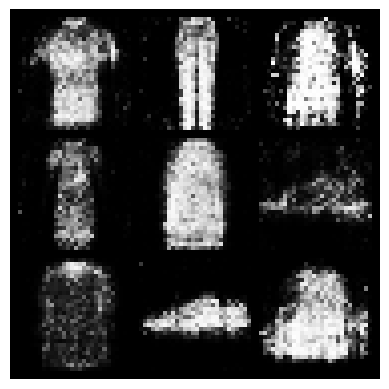

Starting epoch 16...
g_loss: 1.4457988739013672, d_loss: 1.1013047695159912


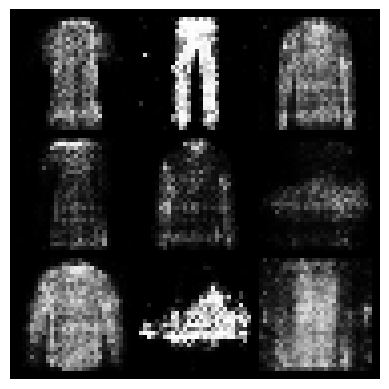

Starting epoch 17...
g_loss: 1.818654179573059, d_loss: 0.8883453011512756


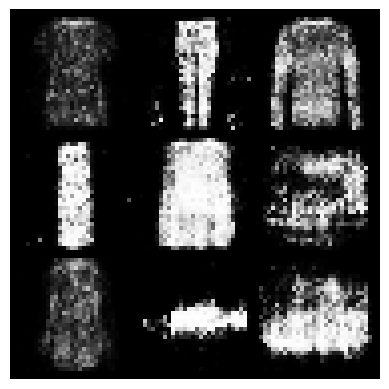

Starting epoch 18...
g_loss: 1.4324781894683838, d_loss: 0.9020114541053772


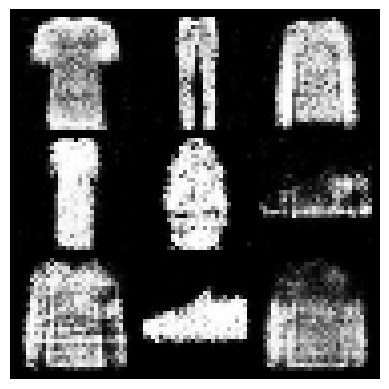

Starting epoch 19...
g_loss: 1.3051990270614624, d_loss: 0.9600595235824585


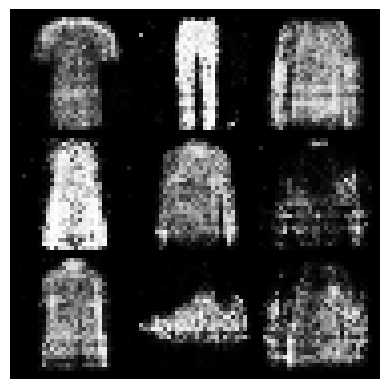

Starting epoch 20...
g_loss: 1.3536324501037598, d_loss: 1.0478239059448242


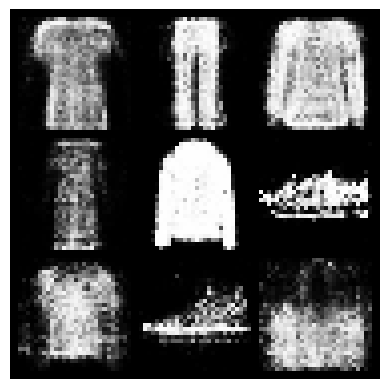

Starting epoch 21...
g_loss: 1.4621808528900146, d_loss: 1.094367504119873


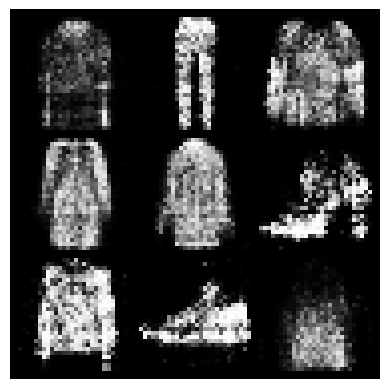

Starting epoch 22...
g_loss: 1.4842047691345215, d_loss: 1.0705845355987549


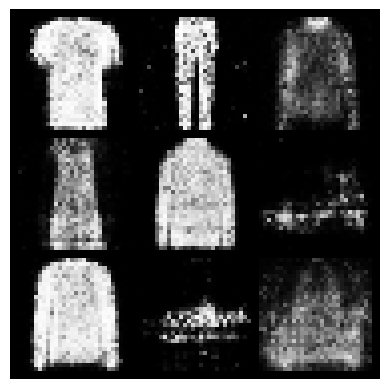

Starting epoch 23...
g_loss: 1.6652501821517944, d_loss: 1.283903956413269


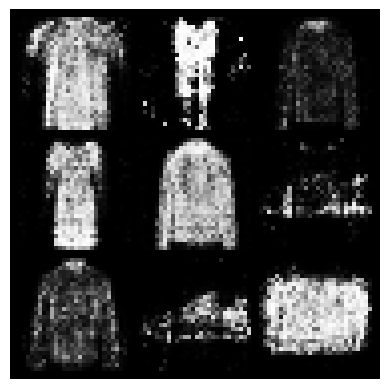

Starting epoch 24...
g_loss: 0.9952329993247986, d_loss: 1.1743509769439697


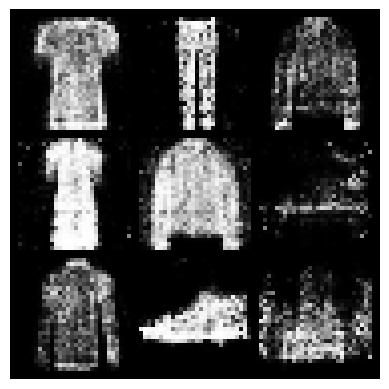

Starting epoch 25...
g_loss: 1.0986601114273071, d_loss: 1.0830769538879395


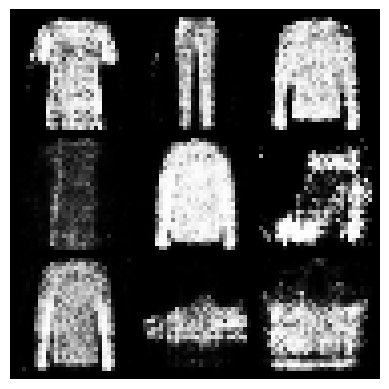

Starting epoch 26...
g_loss: 1.3978984355926514, d_loss: 1.3838346004486084


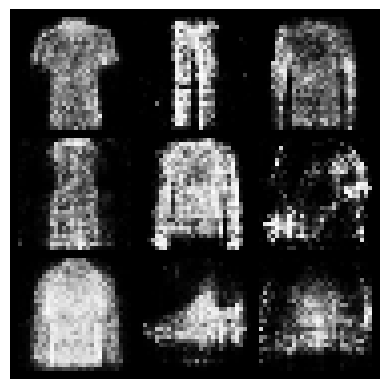

Starting epoch 27...
g_loss: 1.2628062963485718, d_loss: 0.9520925879478455


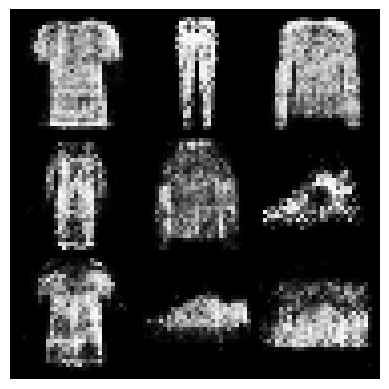

Starting epoch 28...
g_loss: 1.1052337884902954, d_loss: 1.1181018352508545


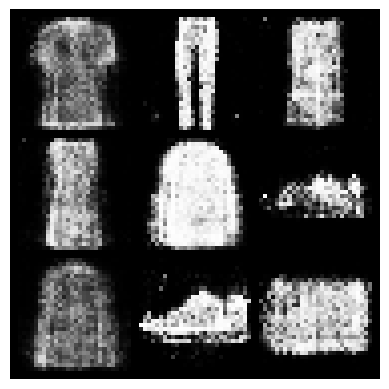

Starting epoch 29...
g_loss: 1.2459959983825684, d_loss: 1.235783338546753


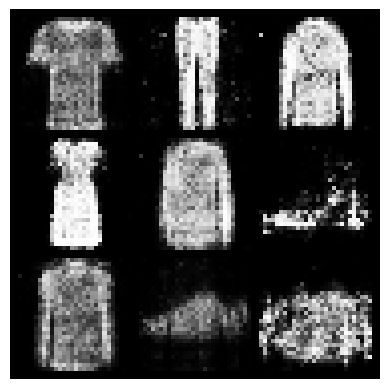

In [11]:
num_epochs = 30
n_critic = 5
display_step = 300
for epoch in range(num_epochs):
    print(f'Starting epoch {epoch}...')
    g_loss = d_loss = 0.0
    for i, (images, labels) in enumerate(data_loader):
        real_images = images.to(device)
        labels = labels.to(device)
        generator.train()
        batch_size = real_images.size(0)
        d_loss = discriminator_train_step(
            len(real_images), discriminator, generator, d_optimizer, criterion, real_images, labels
        )

        g_loss = generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion)

    generator.eval()
    print(f'g_loss: {g_loss}, d_loss: {d_loss}')
    z = torch.randn(9, 100).to(device)
    labels = torch.LongTensor(np.arange(9)).to(device)
    sample_images = generator(z, labels).unsqueeze(1).data.cpu()
    grid = make_grid(sample_images, nrow=3, normalize=True).permute(1, 2, 0).numpy()
    plt.imshow(grid)
    plt.axis('off')
    plt.show()

## 生成新資料

([<matplotlib.axis.XTick at 0x7cd8894ce870>,
 [Text(15, 0, 'T-Shirt'),
  Text(45, 0, 'Trouser'),
  Text(75, 0, 'Pullover'),
  Text(105, 0, 'Dress'),
  Text(135, 0, 'Coat'),
  Text(165, 0, 'Sandal'),
  Text(195, 0, 'Shirt'),
  Text(225, 0, 'Sneaker'),
  Text(255, 0, 'Bag'),
  Text(285, 0, 'Ankle boot')])

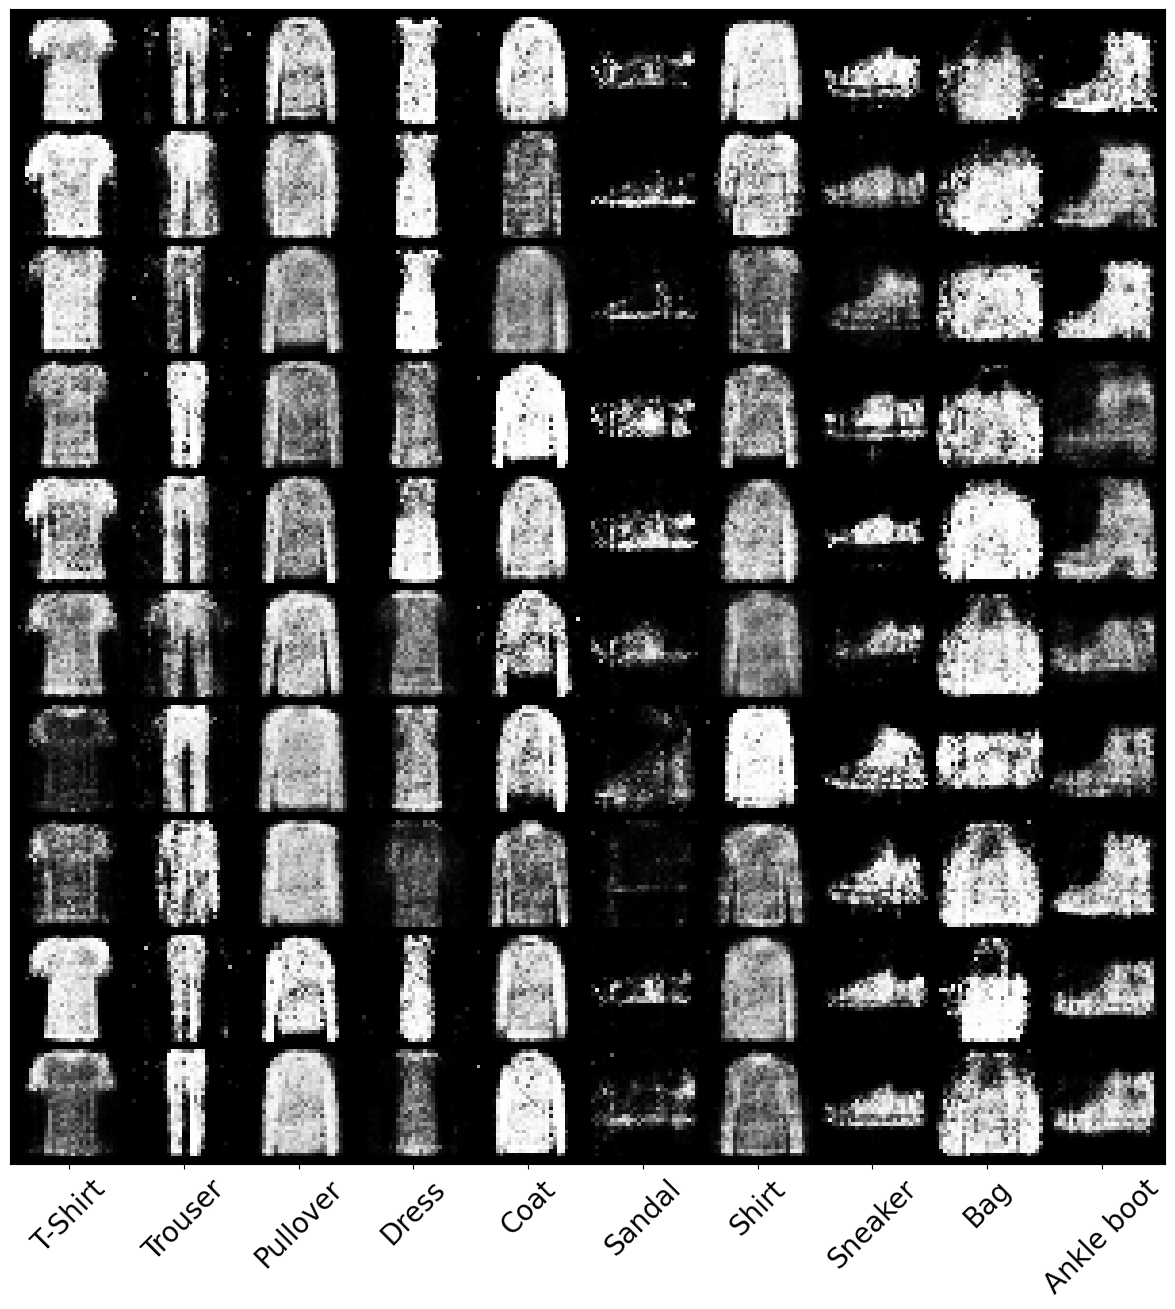

In [12]:
# 標註名稱
label_names = ['T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
z = torch.randn(100, 100).to(device)
labels = torch.LongTensor([i for _ in range(10) for i in range(10)]).to(device)

# 生成圖像
sample_images = generator(z, labels).unsqueeze(1).data.cpu()
grid = make_grid(sample_images, nrow=10, normalize=True).permute(1, 2, 0).numpy()

# 顯示圖像
fig, ax = plt.subplots(figsize=(15, 15))
ax.imshow(grid)
plt.yticks([])
plt.xticks(np.arange(15, 300, 30), label_names, rotation=45, fontsize=20)